# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

**Описание данных:**

Данные геологоразведки трёх регионов находятся в файлах:

/datasets/geo_data_0.csv \
/datasets/geo_data_1.csv \
/datasets/geo_data_2.csv

где:

id — уникальный идентификатор скважины;

f0, f1, f2 — три признака точек (неважно, что они означают, но сами признаки значимы);

product — объём запасов в скважине (тыс. баррелей).

**Условия задачи:**

Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).

При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.

Бюджет на разработку скважин в регионе — 10 млрд рублей.

При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс.
рублей, поскольку объём указан в тысячах баррелей.

После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

Данные синтетические: детали контрактов и характеристики месторождений не разглашаются.

## Загрузка и подготовка данных

In [1]:
!pip install phik

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

import seaborn as sns

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

In [3]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Прочитаем данные и преобразуем столбец 'id' в индекс датафрейма, начинающийся с "0"
geo_data_0 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_0.csv')
geo_data_1 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_1.csv')
geo_data_2 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_2.csv')

In [5]:
geo_data_0.head(2)

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.22117,105.280062
1,2acmU,1.334711,-0.340164,4.36508,73.037750


In [6]:
geo_data_1.head(2)

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261


In [7]:
geo_data_2.head(2)

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697


In [8]:
# Получим общую информацию о датафрэйме
print('Получим общую информацию о датафрэйме geo_data_0:')
geo_data_0.info()

Получим общую информацию о датафрэйме geo_data_0:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [9]:
# Посчитаем количество пропущенных значений (NaN) в каждом столбце датафрейма
print('Количество пропущенных значений (NaN) в каждом столбце датафреймаа geo_data_0:')
geo_data_0.isna().sum()

Количество пропущенных значений (NaN) в каждом столбце датафреймаа geo_data_0:


id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [10]:
# Посчитаем количество явных дубликатов в каждом столбце датафрейма
print('Количество явных дубликатов в каждом столбце датафрейма geo_data_0:')
geo_data_0.duplicated().sum()

Количество явных дубликатов в каждом столбце датафрейма geo_data_0:


0

In [11]:
# Посмотрим уникальные значения в каждом столбце датафрейма для поиска не явных дубликатов
print('Уникальные значения в датафрейме geo_data_0:')
display(geo_data_0['f0'].unique())
display(geo_data_0['f1'].unique())
display(geo_data_0['f2'].unique())
display(geo_data_0['product'].unique())

Уникальные значения в датафрейме geo_data_0:


array([0.70574498, 1.33471129, 1.02273226, ..., 1.02958465, 0.99816289,
       1.76475393])

array([-0.4978225 , -0.34016425,  0.15199044, ...,  0.01878693,
       -0.52858167, -0.26641676])

array([ 1.22116995,  4.36508033,  1.41992624, ..., -1.34830814,
        1.58386866,  5.72284937])

array([105.28006184,  73.03775027,  85.26564713, ...,  64.37544259,
        74.04076435, 149.63324561])

In [12]:
# Явные дубликаты (полное совпадение)
print(f"Число явных дубликатов: {geo_data_0['id'].duplicated().sum()}")
display(geo_data_0[geo_data_0['id'].duplicated(keep=False)].sort_values('id'))

Число явных дубликатов: 10


,id,f0,f1,f2,product
66136,74z30,1.084962,-0.312358,6.990771,127.643327
64022,74z30,0.741456,0.459229,5.153109,140.771492
51970,A5aEY,-0.180335,0.935548,-2.094773,33.020205
3389,A5aEY,-0.039949,0.156872,0.209861,89.249364
69163,AGS9W,-0.933795,0.116194,-3.655896,19.230453
42529,AGS9W,1.454747,-0.479651,0.683380,126.370504
931,HZww2,0.755284,0.368511,1.863211,30.681774
7530,HZww2,1.061194,-0.373969,10.430210,158.828695
63593,QcMuo,0.635635,-0.473422,0.862670,64.578675
1949,QcMuo,0.506563,-0.323775,-2.215583,75.496502


In [13]:
# Размер датафрэйма
print('Размер датафрэйма geo_data_0:')
geo_data_0.shape

Размер датафрэйма geo_data_0:


(100000, 5)

In [14]:
# Получим общую информацию о датафрэйме
print('Получим общую информацию о датафрэйме geo_data_1:')
geo_data_1.info()

Получим общую информацию о датафрэйме geo_data_1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [15]:
# Посчитаем количество пропущенных значений (NaN) в каждом столбце датафрейма
print('Количество пропущенных значений (NaN) в каждом столбце датафреймаа geo_data_1:')
geo_data_1.isna().sum()

Количество пропущенных значений (NaN) в каждом столбце датафреймаа geo_data_1:


id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [16]:
# Посчитаем количество явных дубликатов в каждом столбце датафрейма
print('Количество явных дубликатов в каждом столбце датафрейма geo_data_1:')
geo_data_1.duplicated().sum()

Количество явных дубликатов в каждом столбце датафрейма geo_data_1:


0

In [17]:
# Посмотрим уникальные значения в каждом столбце датафрейма для поиска не явных дубликатов
print('Уникальные значения в датафрейме geo_data_1:')
display(geo_data_1['f0'].unique())
display(geo_data_1['f1'].unique())
display(geo_data_1['f2'].unique())
display(geo_data_1['product'].unique())

Уникальные значения в датафрейме geo_data_1:


array([-15.00134818,  14.27208781,   6.26318735, ...,  -7.37889139,
         0.66571381,  -3.42613898])

array([-8.27599995, -3.47508322, -5.94838579, ..., -3.08410387,
       -6.15259286, -7.7942742 ])

array([-5.87601369e-03,  9.99182737e-01,  5.00116016e+00, ...,
        4.99865060e+00,  1.00014635e+00, -3.29851829e-03])

array([  3.17910258,  26.95326103, 134.76630516, 137.94540774,
        84.03888568, 110.99214671,  53.90652206,   0.        ,
       107.81304413,  57.08562465,  30.13236361,  80.85978309])

In [18]:
# Явные дубликаты (полное совпадение)
print(f"Число явных дубликатов: {geo_data_1['id'].duplicated().sum()}")
display(geo_data_1[geo_data_1['id'].duplicated(keep=False)].sort_values('id'))

Число явных дубликатов: 4


,id,f0,f1,f2,product
5849,5ltQ6,-3.435401,-12.296043,1.999796,57.085625
84461,5ltQ6,18.213839,2.191999,3.993869,107.813044
1305,LHZR0,11.170835,-1.945066,3.002872,80.859783
41906,LHZR0,-8.989672,-4.286607,2.009139,57.085625
2721,bfPNe,-9.494442,-5.463692,4.006042,110.992147
82178,bfPNe,-6.202799,-4.820045,2.995107,84.038886
47591,wt4Uk,-9.091098,-8.109279,-0.002314,3.179103
82873,wt4Uk,10.259972,-9.376355,4.994297,134.766305


In [19]:
# Размер датафрэйма
print('Размер датафрэйма geo_data_1:')
geo_data_1.shape

Размер датафрэйма geo_data_1:


(100000, 5)

In [20]:
# Получим общую информацию о датафрэйме
print('Получим общую информацию о датафрэйме geo_data_2:')
geo_data_2.info()

Получим общую информацию о датафрэйме geo_data_2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [21]:
# Посчитаем количество пропущенных значений (NaN) в каждом столбце датафрейма
print('Количество пропущенных значений (NaN) в каждом столбце датафреймаа geo_data_2:')
geo_data_2.isna().sum()

Количество пропущенных значений (NaN) в каждом столбце датафреймаа geo_data_2:


id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [22]:
# Посчитаем количество явных дубликатов в каждом столбце датафрейма
print('Количество явных дубликатов в каждом столбце датафрейма geo_data_2:')
geo_data_2.duplicated().sum()

Количество явных дубликатов в каждом столбце датафрейма geo_data_2:


0

In [23]:
# Посмотрим уникальные значения в каждом столбце датафрейма для поиска не явных дубликатов
print('Уникальные значения в датафрейме geo_data_2:')
display(geo_data_2['f0'].unique())
display(geo_data_2['f1'].unique())
display(geo_data_2['f2'].unique())
display(geo_data_2['product'].unique())

Уникальные значения в датафрейме geo_data_2:


array([-1.1469871 ,  0.2627779 ,  0.19458728, ..., -1.19993432,
       -2.41989641, -2.55142066])

array([ 0.96332792,  0.26983896,  0.289035  , ..., -2.95763723,
        2.41722066, -2.02562514])

array([-0.82896492, -2.53018652, -5.58643277, ...,  5.219411  ,
       -5.54844392,  6.09089066])

array([ 27.75867323,  56.06969663,  62.87191005, ..., 157.08007975,
        51.79525299, 102.77576749])

In [24]:
# Явные дубликаты (полное совпадение)
print(f"Число явных дубликатов: {geo_data_2['id'].duplicated().sum()}")
display(geo_data_2[geo_data_2['id'].duplicated(keep=False)].sort_values('id'))

Число явных дубликатов: 4


,id,f0,f1,f2,product
45404,KUPhW,0.231846,-1.698941,4.990775,11.716299
55967,KUPhW,1.211150,3.176408,5.543540,132.831802
11449,VF7Jo,2.122656,-0.858275,5.746001,181.716817
49564,VF7Jo,-0.883115,0.560537,0.723601,136.233420
44378,Vcm5J,-1.229484,-2.439204,1.222909,137.968290
95090,Vcm5J,2.587702,1.986875,2.482245,92.327572
28039,xCHr8,1.633027,0.368135,-2.378367,6.120525
43233,xCHr8,-0.847066,2.101796,5.597130,184.388641


In [25]:
# Преобразуем столбец 'id' в индекс датафрейма, начинающийся с "0"
geo_data_0 = geo_data_0.set_index('id')
geo_data_1 = geo_data_1.set_index('id')
geo_data_2 = geo_data_2.set_index('id')

In [26]:
# Размер датафрэйма
print('Размер датафрэйма geo_data_2:')
geo_data_2.shape

Размер датафрэйма geo_data_2:


(100000, 4)

In [27]:
geo_data_1.head(2)

,f0,f1,f2,product
id,,,,
kBEdx,-15.001348,-8.276000,-0.005876,3.179103
62mP7,14.272088,-3.475083,0.999183,26.953261


interval columns not set, guessing: ['f0', 'f1', 'f2', 'product']


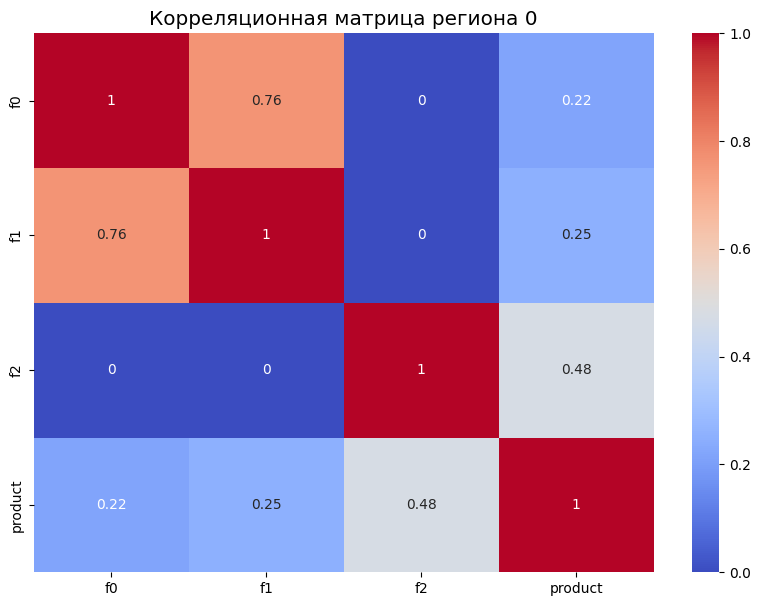

In [28]:
# Для того, чтобы убедиться в отсутствии мультиколлиниарности
# при последующем использовании линейной модели МО,
# составим матрицу корреляции для региона 0
# при наличии мультиклнрн не будем использовать такие признаки при МО линейной модели
# Чисолвые непрерывные признаки

# Создаем DataFrame из данных
geo_data_0_df = pd.DataFrame(geo_data_0)

# Указываем числовые признаки для анализа
interval_cols = ['f0', 'f1', 'f2', 'product']

# Вычисляем матрицу корреляций Phik для выбранных признаков
phik_corr = geo_data_0_df[interval_cols].phik_matrix()

# Визуализируем матрицу тепловой картой
plt.figure(figsize=(10, 7))
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.rcParams['font.size'] = 12
plt.title('Корреляционная матрица региона 0')
plt.show()

interval columns not set, guessing: ['f0', 'f1', 'f2', 'product']


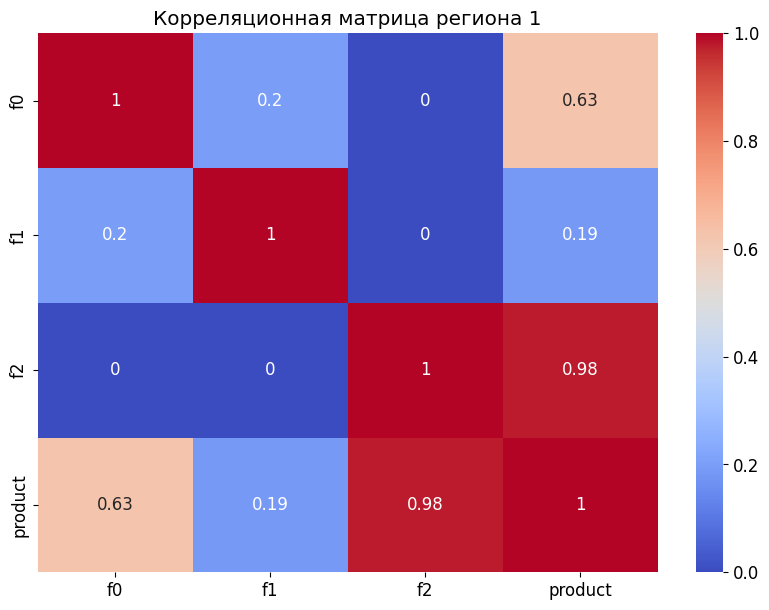

In [29]:
# Для того, чтобы убедиться в отсутствии мультиколлиниарности
# при последующем использовании линейной модели МО,
# составим матрицу корреляции для региона 1
# при наличии мультиклнрн не будем использовать такие признаки при МО линейной модели
# Чисолвые непрерывные признаки

# Создаем DataFrame из данных
geo_data_1_df = pd.DataFrame(geo_data_1)

# Указываем числовые признаки для анализа
interval_cols = ['f0', 'f1', 'f2', 'product']

# Вычисляем матрицу корреляций Phik для выбранных признаков
phik_corr = geo_data_1_df[interval_cols].phik_matrix()

# Визуализируем матрицу тепловой картой
plt.figure(figsize=(10, 7))
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.rcParams['font.size'] = 12
plt.title('Корреляционная матрица региона 1')
plt.show()

interval columns not set, guessing: ['f0', 'f1', 'f2', 'product']


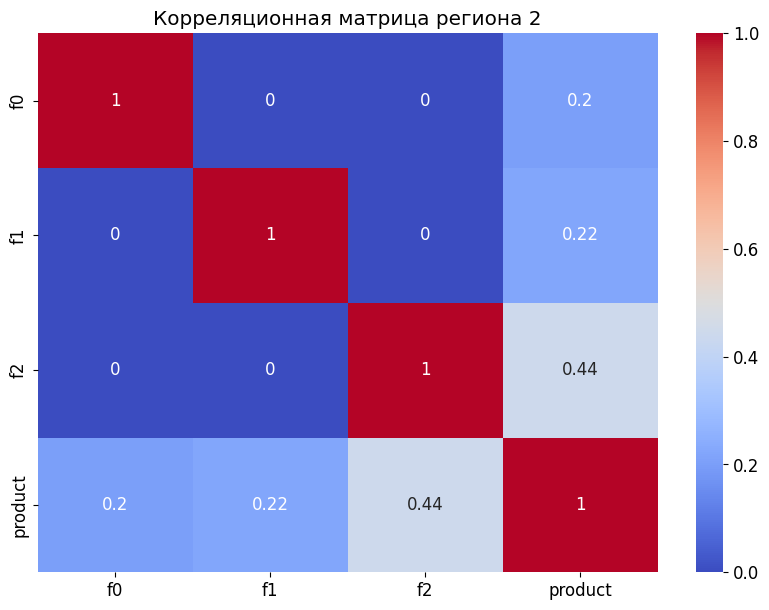

In [30]:
# Для того, чтобы убедиться в отсутствии мультиколлиниарности
# при последующем использовании линейной модели МО,
# составим матрицу корреляции для региона 2
# при наличии мультиклнрн не будем использовать такие признаки при МО линейной модели
# Чисолвые непрерывные признаки

# Создаем DataFrame из данных
geo_data_2_df = pd.DataFrame(geo_data_2)

# Указываем числовые признаки для анализа
interval_cols = ['f0', 'f1', 'f2', 'product']

# Вычисляем матрицу корреляций Phik для выбранных признаков
phik_corr = geo_data_2_df[interval_cols].phik_matrix()

# Визуализируем матрицу тепловой картой
plt.figure(figsize=(10, 7))
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.rcParams['font.size'] = 12
plt.title('Корреляционная матрица региона 2')
plt.show()

In [31]:
# Снизим мультиколиниарность


**Вывод по предобработке данных.**

Для чтения данных была импортирована библиотека pandas. Далее по ходу проекта при необходимости также будут импортироваться библиотеки.

Преобразован id в индексы, начиная с "0".

Датафрэймы одного размера, названия столбцов и типов данных в них совпадают для всех датафрэймов.

Пропуски отсутствуют.

Явные дубликаты присутствуют, но, значения в id совпадают, а в следующих столбцах для них - нет, не удаляем явные дубликаты. Числовые значения тоже могут совпадать - не удаляем.

Датафрэймы были преобразованы:
- id преобразованы в индексы,
- данные в столбцах для эргономичности визуального восприятия округлены.

Проведен корелляционный анализ датафрэймов для определения мультиколлиниарности между признаками. В регионе 1 обнаружена мультиколлиниарность между признаками f2 и prodact. В связи с этим, при МО для региона 1 проведем Ridge-регрессию (L2-регуляризацию).

## Обучение и проверка модели

In [32]:
RANDOM_STATE = 42

### Обучение и проверка модели 0


In [33]:
# Разобьем датафрэйм на тренеровочный и валидационный, зададим процент
# валидационной выборки
X0 = geo_data_0.drop('product', axis = 1)
y0 = geo_data_0['product']
X0_train, X0_valid, y0_train, y0_valid = train_test_split(
        X0, 
        y0, 
        test_size=0.25,
        random_state=RANDOM_STATE
) 

In [34]:
# Выполним масштабирование (нормализацию) данных с помощью класса StandardScaler
# из библиотеки sklearn.preprocessing - приведение данных к одному масштабу
# В результате получится новая версия обучающего набора данных X0_train/valid_scaler, 
# масштабированная так, что каждое признаковое значение будет иметь 
# среднее около 0 и стандартное отклонение около 1.
scaler0 = StandardScaler()
X0_train_scaler = scaler0.fit_transform(X0_train)
X0_valid_scaler = scaler0.transform(X0_valid)


In [35]:
# Обучим модель 0 линейной регрессии и используем её для предсказания на 
# валидационных данных
# Создадим модель 0 для поиска линейной зависимости между признаками и целевой переменной
model_0 = LinearRegression()
model_0.fit(X0_train_scaler, y0_train)
# Используем обученную модель для предсказания значений целевой переменной на новых данных
predict_0 = model_0.predict(X0_valid_scaler)

In [36]:
# Выведем среднее значение предсказанных данных - средний запас сырья в данных модели 0
mean_0 = predict_0.mean()
mean_0.round(2)

92.4

Для оценки качества модели линейной регрессии (как сказанов условии-ЛР) будем использовать метрику качества модели RMSE. 
___
RMSE (Root Mean Squared Error, корень из среднеквадратичной ошибки) — это популярная метрика для оценки качества моделей регрессии.
___
Интерпретируемость:

RMSE выражается в тех же единицах, что и целевая переменная (например, тонны, деньги, метры). Это облегчает понимание того, насколько точны предсказания модели.
___
Чувствительность к большим ошибкам:

За счет возведения ошибок в квадрат RMSE придает больше веса крупным отклонениям. Это помогает выявить модели, которые иногда делают очень большие ошибки.
___
Общепринятость:

RMSE широко используется в научных исследованиях и практике, что делает её хорошим стандартом для сравнения моделей.
___
Дифференцируемость:

В отличие от некоторых метрик, RMSE — дифференцируемая функция (у нее есть производная в любой точке, тк это квадратичная функция), что важно для методов оптимизации и обучения моделей.
_____
Почему именно RMSE, а не MAE или другие метрики?

RMSE сильнее, чем MAE, тк показывает в квадрате ошибки, что полезно, если крупные ошибки нежелательны.

В то же время, RMSE чувствительна к выбросам и крупным ошибкам, что иногда является плюсом или минусом в зависимости от задачи.

Итак:
RMSE используют потому что она дает понятную и чувствительную оценку точности регрессионных моделей, особенно когда важна степень крупной ошибки.

In [37]:
mse = mean_squared_error(y0_valid, predict_0)
rmse_0 = mse ** 0.5
print(f'Средний запас предсказанного сырья (тыс. баррелей):')
mean_0.round()

Средний запас предсказанного сырья (тыс. баррелей):


92.0

In [38]:
print('Значение метрики RMSE:')
print('Отдельные предсказания могут отклоняться от реальных значений примерно на', rmse_0, '(тысяч баррелей)')

Значение метрики RMSE:
Отдельные предсказания могут отклоняться от реальных значений примерно на 37.75660035026169 (тысяч баррелей)


### Обучение и проверка модели 1

In [39]:
# Разобьем датафрэйм на тренеровочный и валидационный, зададим процент
# валидационной выборки
X1 = geo_data_1.drop('product', axis = 1)
y1 = geo_data_1['product']
X1_train, X1_valid, y1_train, y1_valid = train_test_split(
        X1, 
        y1, 
        test_size=0.20,
        random_state=RANDOM_STATE
)

In [40]:
# Выполним масштабирование (нормализацию) данных с помощью класса StandardScaler
# из библиотеки sklearn.preprocessing - приведение данных к одному масштабу
# В результате получится новая версия обучающего набора данных X1_train/valid_scaler, 
# масштабированная так, что каждое признаковое значение будет иметь 
# среднее около 1 и стандартное отклонение около 1.
scaler1 = StandardScaler()
X1_train_scaler = scaler1.fit_transform(X1_train)
X1_valid_scaler = scaler1.transform(X1_valid)

In [41]:
# Создание и обучение Ridge-модели
ridge = Ridge(alpha=1.0)  # можно попробовать другие значения alpha
ridge.fit(X1_train_scaler, y1_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [42]:
# Обучим модель 1 линейной регрессии и используем её для предсказания на 
# валидационных данных
# Создадим модель 1 для поиска линейной зависимости между признаками и целевой переменной
model_1 = LinearRegression()
model_1.fit(X1_train_scaler, y1_train)
# Используем обученную модель для предсказания значений целевой переменной на новых данных
predict_1 = ridge.predict(X1_valid_scaler)

In [43]:
# Выведем среднее значение предсказанных данных - средний запас сырья в данных модели 0
mean_1 = predict_1.mean()
mean_1.round(2)

68.33

In [44]:
mse = mean_squared_error(y1_valid, predict_1)
rmse_1 = mse ** 0.5
print(f'Средний запас предсказанного сырья (тыс. баррелей):')
mean_1.round(2)

Средний запас предсказанного сырья (тыс. баррелей):


68.33

In [45]:
print(f'Значение метрики RMSE:')
print('Отдельные предсказания могут отклоняться от реальных значений примерно на', rmse_1, '(тысяч баррелей)')

Значение метрики RMSE:
Отдельные предсказания могут отклоняться от реальных значений примерно на 0.8908387637201415 (тысяч баррелей)


### Обучение и проверка модели 2

In [46]:
# Разобьем датафрэйм на тренеровочный и валидационный, зададим процент
# валидационной выборки
X2 = geo_data_2.drop('product', axis = 1)
y2 = geo_data_2['product']
X2_train, X2_valid, y2_train, y2_valid = train_test_split(
        X2, 
        y2, 
        test_size=0.20,
        random_state=RANDOM_STATE
)

In [47]:
# Выполним масштабирование (нормализацию) данных с помощью класса StandardScaler
# из библиотеки sklearn.preprocessing - приведение данных к одному масштабу
# В результате получится новая версия обучающего набора данных X2_train/valid_scaler, 
# масштабированная так, что каждое признаковое значение будет иметь 
# среднее около 2 и стандартное отклонение около 2.
scaler2 = StandardScaler()
X2_train_scaler = scaler2.fit_transform(X2_train)
X2_valid_scaler = scaler2.transform(X2_valid)

In [48]:
# Обучим модель 2 линейной регрессии и используем её для предсказания на 
# валидационных данных
# Создадим модель 2 для поиска линейной зависимости между признаками и целевой переменной
model_2 = LinearRegression()
model_2.fit(X2_train_scaler, y2_train)
# Используем обученную модель для предсказания значений целевой переменной на новых данных
predict_2 = model_2.predict(X2_valid_scaler)

In [49]:
# Выведем среднее значение предсказанных данных - средний запас сырья в данных модели 0
mean_2 = predict_2.mean()
mean_2.round(2)

94.86

In [50]:
mse = mean_squared_error(y2_valid, predict_2)
rmse_2 = mse ** 0.5
print(f'Средний запас предсказанного сырья (тыс. баррелей):')
mean_2.round(2)

Средний запас предсказанного сырья (тыс. баррелей):


94.86

In [51]:
print(f'Значение метрики RMSE:')
print('Отдельные предсказания могут отклоняться от реальных значений примерно на', rmse_1, '(тысяч баррелей)')

Значение метрики RMSE:
Отдельные предсказания могут отклоняться от реальных значений примерно на 0.8908387637201415 (тысяч баррелей)


In [52]:
# Создаем словарь с данными
geo_data_012 = {
    'Mean': [mean_0, mean_1, mean_2],
    'RMSE': [rmse_0, rmse_1, rmse_2]
}

# Создаем DataFrame
geo_data_012 = pd.DataFrame(geo_data_012, index=['Регион 0', 'Регион 1', 'Регион 2'])

# Выводим таблицу
display(geo_data_012.sort_values(by='RMSE', ascending=True))

,Mean,RMSE
Регион 1,68.332894,0.890839
Регион 0,92.398800,37.756600
Регион 2,94.859026,40.157688


**Вывод 2**

В регионе 2 самые большие запасы нефти - 94+ тыс баррелей. Чуть меньшие - в регионе 0 - 92+ тыс баррелей, но ошибка моделей для них составляет 37-40 тыс баррелей, то есть ошибка около 50%.

В регионе 1 запасов нефти меньше всего 68+. Но и ошибка для модели для этого региона всего 0,89 тыс баррелей, то есть около 1%.

## Подготовка к расчёту прибыли

In [53]:
# При разведке региона исследуют 500 точек, 
# из которых с помощью машинного обучения выбирают 200 лучших для разработки.
n = 200
# Бюджет на разработку скважин в регионе - 10 млрд. рублей
budget = 10*10**9
# Доход с каждой единицы продукта составляет 450 тыс. рублей, 
# поскольку объём указан в тысячах баррелей
revenue = 450*10**3

In [54]:
# На одну скважину выделяется
budget_one = budget/n
print('На одну скважину выделяется', budget_one, 'рублей')
# Сколько должно быть в скаважене продукта, чтобы потратить выделенный бюджет
volume = budget_one / revenue
volume = round(volume, 2)
print('Для выхода на доход со скважины', revenue, 'рублей', 'объем продукта в одной скважине должен быть более', volume, 'тыс баррелей')

На одну скважину выделяется 50000000.0 рублей
Для выхода на доход со скважины 450000 рублей объем продукта в одной скважине должен быть более 111.11 тыс баррелей


**Вывод 3**

Для безубыточности объем каждой скважины должен быть более 111.11 тыс. баррелей.

Средние значения запасов в скважинах по регионам меньше:
- регион 0 - 92+ тыс баррелей
- регион 1 - 68+ тыс баррелей
- регион 2 - 94+ тыс баррелей

Значит. Либо в регионах объем скважин > 200*111.11, либо освоение скважин в регионах будет заведомо убыточным.

## Расчёт прибыли и рисков 

In [55]:
# Оценка прибыли на основе предсказаний модели и реальных данных
def profit(data, y_true, y_predict):
    data['predict'] = y_predict
    # Массив с реальными значениями (фактическими запасами сырья)
    data['true'] = y_true
    # Сортируем по убыванию и выбираем 200 наиболее объемных скважин
    data = data.sort_values(by = 'predict', ascending = False)
    data = data.head(n)
    # суммируем реальные значения и умножаем их на стоимость одного барреля сырья и вычитаем
    # бюджет разработки скважин в регионе
    profite = data['true'].sum()*revenue - budget
    return profite

In [56]:
state = np.random.RandomState(2007)

In [57]:
points = 500

In [58]:
# Регион 0
# Создадим список prib0, в который будут сохраняться результаты (прибыль) 
# для каждого повторного выборочного анализа.
prib0 = []
for i in range(1000):
    subsample = X0_valid.sample(n=points, replace = True, random_state=state)
    prib0.append(profit(subsample, y0_valid, pd.DataFrame(predict_0, index = X0_valid.index)))

In [59]:
# Регион 1
# Создадим список prib1, в который будут сохраняться результаты (прибыль) 
# для каждого повторного выборочного анализа.
prib1 = []
for i in range(1000):
    subsample = X1_valid.sample(n=points, replace = True, random_state=state)
    prib1.append(profit(subsample, y1_valid, pd.DataFrame(predict_1, index = X1_valid.index)))

In [60]:
# Регион 2
# Создадим список prib2, в который будут сохраняться результаты (прибыль) 
# для каждого повторного выборочного анализа.
prib2 = []
for i in range(1000):
    subsample = X2_valid.sample(n=points, replace = True, random_state=state)
    prib2.append(profit(subsample, y2_valid, pd.DataFrame(predict_2, index = X2_valid.index)))

In [61]:
# Регион 0. Средняя прибыль
print('Средняя прибыль для региона 0:', pd.Series(prib0).mean().round(0), 'рублей')

Средняя прибыль для региона 0: 386778345.0 рублей


In [62]:
# Регион 1. Средняя прибыль
print('Средняя прибыль для региона 1:', pd.Series(prib1).mean().round(0), 'рублей')

Средняя прибыль для региона 1: 424483853.0 рублей


In [63]:
# Регион 2. Средняя прибыль
print('Средняя прибыль для региона 2:', pd.Series(prib2).mean().round(0), 'рублей')

Средняя прибыль для региона 2: 341388048.0 рублей


In [64]:
# Создаем словарь с данными
prib_012 = {
    'Средняя прибыль': [pd.Series(prib0).mean().round(0), pd.Series(prib1).mean().round(0), pd.Series(prib2).mean().round(0)]
}

# Создаем DataFrame
prib_012 = pd.DataFrame(prib_012, index=['Регион 0', 'Регион 1', 'Регион 2'])

# Выводим таблицу
display(prib_012.sort_values(by='Средняя прибыль', ascending=False))

,Средняя прибыль
Регион 1,424483853.0
Регион 0,386778345.0
Регион 2,341388048.0


In [65]:
# После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков 
# меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.
# Найдем квантили - с каждой стороны возьмем по 1.25%
# Найдём 97.5% доверительный интервал
lower = pd.Series(prib0).quantile(0.025).round(2)
upper = pd.Series(prib0).quantile(0.975).round(2)
print('Доверительный интервал прибыли в регионе 0 составляет от:')
print(lower, 'рублей')
print('до:')
print(upper, 'рублей')

Доверительный интервал прибыли в регионе 0 составляет от:
-154352702.67 рублей
до:
882800772.53 рублей


In [66]:
# Регион 1
lower = pd.Series(prib1).quantile(0.025).round(2)
upper = pd.Series(prib1).quantile(0.975).round(2)
print('Доверительный интервал прибыли в регионе 1 составляет от:')
print(lower, 'рублей')
print('до:')
print(upper, 'рублей')

Доверительный интервал прибыли в регионе 1 составляет от:
40227092.21 рублей
до:
802593342.18 рублей


In [67]:
# Регион 2
lower = pd.Series(prib2).quantile(0.025).round(2)
upper = pd.Series(prib2).quantile(0.975).round(2)
print('Доверительный интервал прибыли в регионе 2 составляет от:')
print(lower, 'рублей')
print('до:')
print(upper, 'рублей')

Доверительный интервал прибыли в регионе 2 составляет от:
-210403132.86 рублей
до:
854599874.46 рублей


In [68]:
# Регион 0
# Доля отрицательных значений прибыли
# список всех значений прибыли < 0 - считаем сколько таких значений 
# делим на общее число всех значений прибыли
len([i for i in prib0 if i<0])/len(prib0)*100

7.8

In [69]:
# Регион 1
# Доля отрицательных значений прибыли
len([i for i in prib1 if i<0])/len(prib1)*100

1.6

In [70]:
# Регион 2
# Доля отрицательных значений прибыли
len([i for i in prib2 if i<0])/len(prib2)*100

10.9

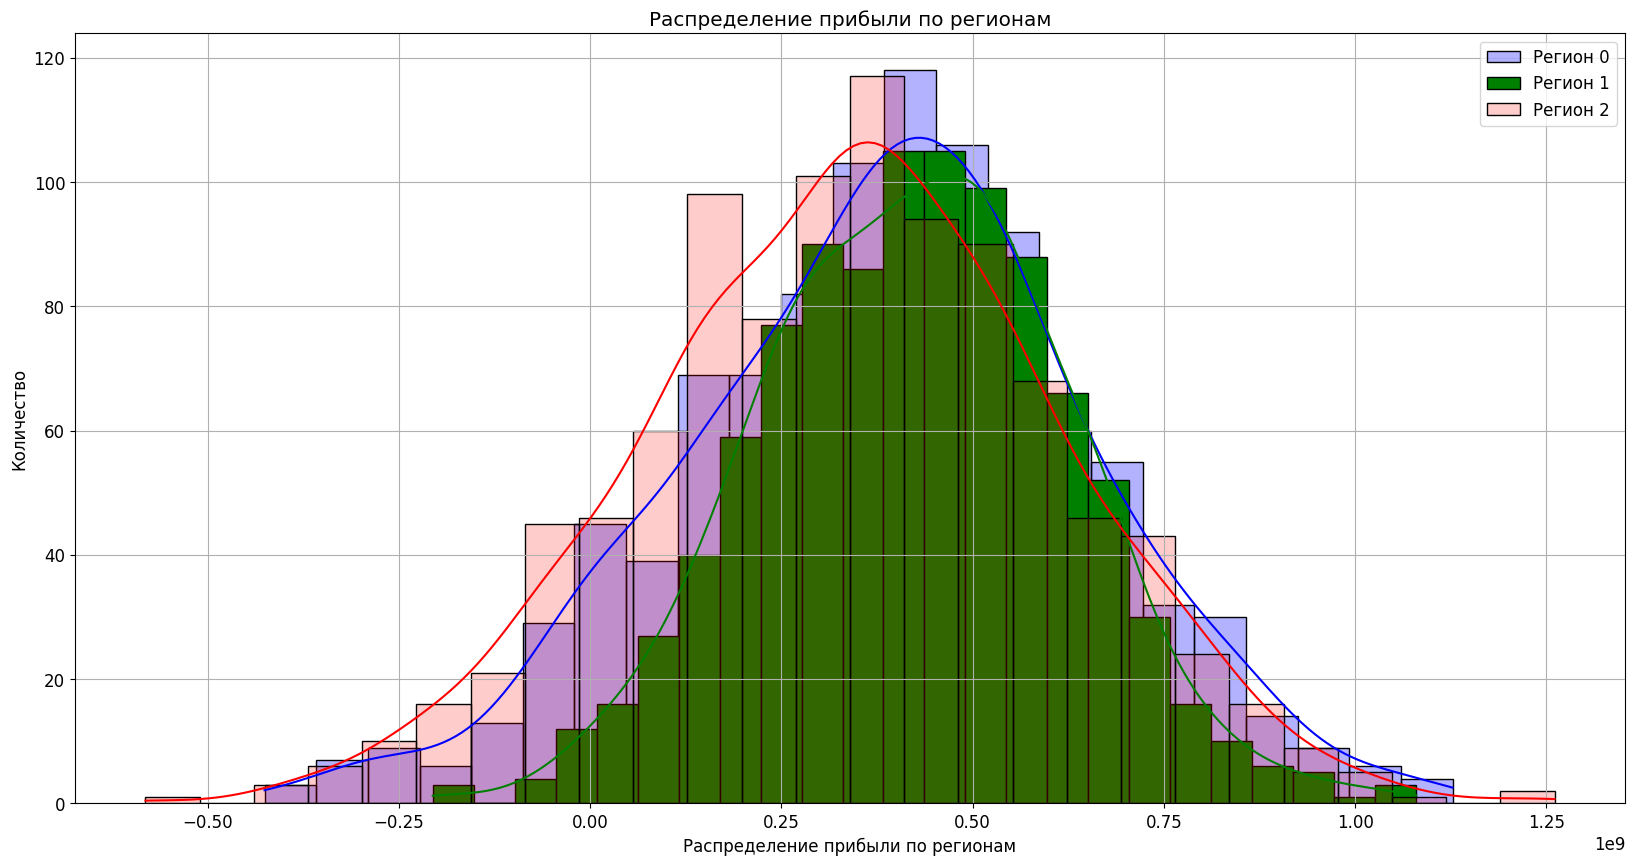

In [71]:
# Построение гистограммы
plt.figure(figsize=(20, 10)) 
sns.histplot(prib0, kde=True, color='blue', alpha=0.3, label='Регион 0')
sns.histplot(prib1, kde=True, color='green', alpha=1, label='Регион 1')
sns.histplot(prib2, kde=True, color='red', alpha=0.2, label='Регион 2')
plt.title('Распределение прибыли по регионам')
plt.xlabel('Распределение прибыли по регионам')
plt.ylabel('Количество')
plt.legend()
plt.grid(True)

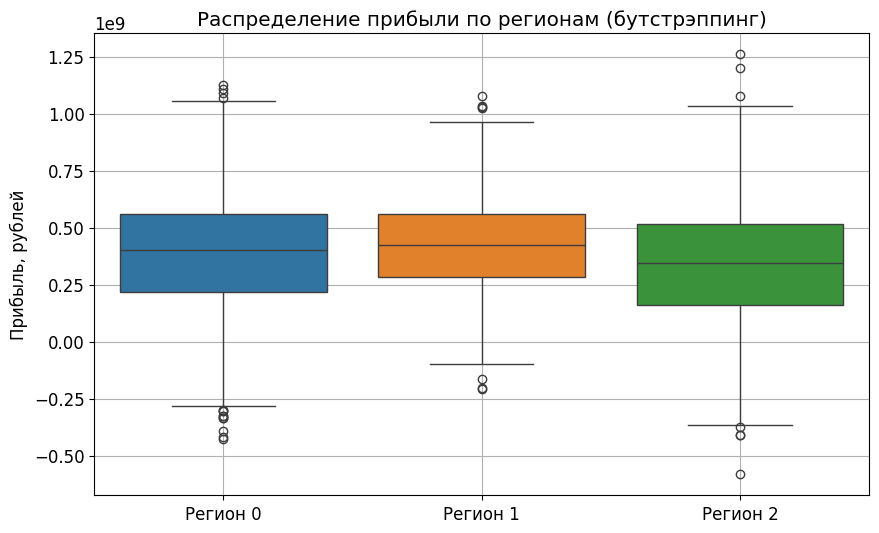

In [72]:
# Визуализируем распределение прибыли для регионов 0, 1, 2 с помощью ящика с усами
df_prib = pd.DataFrame({
    'Регион 0': prib0,
    'Регион 1': prib1,
    'Регион 2': prib2
})

# Построение ящика с усами
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_prib)
plt.title('Распределение прибыли по регионам (бутстрэппинг)')
plt.ylabel('Прибыль, рублей')
plt.xlabel('')
plt.grid(True)
plt.show()

**Расчеты и визуализация распределений прибыли** показывает, что **в регионе 1 лучшие показатели**:
- минимальное количество отрицательных значений прибыли,
- медиана прибыли выше в регионе 1.
- выбросов в регионе 1 меньше, чем в других, значит и ошибок меньше - важно при оценке качества работы линейной модели МО.

**Вывод 4**

Регион, в котором вероятность отрицательной прибыли (убытков) меньше 2.5% - это регион 1.

Кроме того, регион 1 - единственный из представленных регионов, в котором **отсутствуют отрицательные значения прибыли (убытки) в 95% интервале**. Значит, с вероятностью 95% (хотя в моем университете было недопустимо вероятность измерять в %), так вот, с вероятностью 95% в регионе 1 будет прибыль, а не убытки.

**Средняя прибыль** в этом регионе максимальная в сравнении с другими регионами. она составляет **430 425 219.0 рублей**.

Соответственно, **регион 1** и следует **выбирать для разработки месторождений**.

## Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнен шаг 1: данные подготовлены
- [x]  Выполнен шаг 2: модели обучены и проверены
    - [x]  Данные корректно разбиты на обучающую и валидационную выборки
    - [x]  Модели обучены, предсказания сделаны
    - [x]  Предсказания и правильные ответы на валидационной выборке сохранены
    - [x]  На экране напечатаны результаты
    - [x]  Сделаны выводы
- [x]  Выполнен шаг 3: проведена подготовка к расчёту прибыли
    - [x]  Для всех ключевых значений созданы константы Python
    - [x]  Посчитано минимальное среднее количество продукта в месторождениях региона, достаточное для разработки
    - [x]  По предыдущему пункту сделаны выводы
    - [x]  Написана функция расчёта прибыли
- [x]  Выполнен шаг 4: посчитаны риски и прибыль
    - [x]  Проведена процедура *Bootstrap*
    - [x]  Все параметры бутстрепа соответствуют условию
    - [x]  Найдены все нужные величины
    - [x]  Предложен регион для разработки месторождения
    - [x]  Выбор региона обоснован